# TUGAS KELOMPOK NLP
Nama:

*   Rizki Dwi Sya'bana Nugraha (10522120)
*   Nur Aisah (10522125)
*   Hilman Fauzi Abdilah (10522034)
*   Sandy Permana (10522013)


**Text Classification**

Dataset : https://github.com/agus235032/natural_lp/blob/master/tweet.csv

Jumlah dataset: 7527

Dataset ini berisi tweet/aduan masyarakat berbahasa Indonesia yang ditujukan kepada Pemerintah Kota Bandung (mention ke akun Ridwan Kamil & dinas terkait), digunakan untuk tugas klasifikasi teks.

**Klasifikasi Teks Menggunakan Machine Learning, Deep Learning, dan Pre-Training IndoBERT**



# Import Library

In [ ]:
!pip -q install Sastrawi

In [ ]:
!pip install --upgrade git+https://github.com/ariaghora/mpstemmer.git
!pip install python-Levenshtein

  Cloning https://github.com/ariaghora/mpstemmer.git to /tmp/pip-req-build-5lj8_9xa
  Running command git clone --filter=blob:none --quiet https://github.com/ariaghora/mpstemmer.git /tmp/pip-req-build-5lj8_9xa
  Resolved https://github.com/ariaghora/mpstemmer.git to commit 25a5fd923af163a7eac3a5ec976984156ca8fa8b
  Preparing metadata (setup.py) ... done


In [ ]:
!pip install gensim

In [ ]:
# !pip uninstall nltk -y
# !pip install --upgrade nltk

Found existing installation: nltk 3.9.1
Uninstalling nltk-3.9.1:
  Successfully uninstalled nltk-3.9.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.6 MB/s eta 0:00:00


In [ ]:
!pip install imblearn

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 766.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 118.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 87.2 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
# import comman libary
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

# import nltk libarary for text pre-processing
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from mpstemmer import MPStemmer

# import sklearn libarary for feature extraction
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from gensim.models import Word2Vec
from imblearn.over_sampling import SMOTE

# import sklearn libary for modelling
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
# import algorithms
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# import sklearn for calculate evaluation
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Embedding, SimpleRNN, LSTM, Dense, Dropout, Concatenate
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
mps = MPStemmer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load Dataset

In [ ]:
df_data = pd.read_csv('tweet.csv', sep=';', encoding='latin-1')
df_data.head()

,Tweet,Classfy
0,@ridwankamil @dbmpkotabdg kang teman saya tert...,Keluhan
1,@dbmpkotabdg RT @fajriattack: Lapor pak @ridwa...,Keluhan
2,Pa @ridwankamil tempat kerja saya tgl 25 tetep...,Keluhan
3,"@pdamtirtawening@ridwankamil 00106700466, pun...",Keluhan
4,RT @KendiAdiputra: Anak SMA yang ketahuan menc...,Keluhan


In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7527 entries, 0 to 7526
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Tweet    7527 non-null   object
 1   Classfy  7527 non-null   object
dtypes: object(2)
memory usage: 117.7+ KB


In [ ]:
# Mengecek missing value
print("Jumlah missing value pada setiap kolom:")
df_data.isnull().sum()

Jumlah missing value pada setiap kolom:


,0
Tweet,0
Classfy,0


In [ ]:
# Mengecek duplikasi data
print("Jumlah dupikat data:")
print(df_data.duplicated().sum())

Jumlah dupikat data:
2436


In [ ]:
# Menghapus baris yang duplikat
df_data.drop_duplicates(inplace=True)
df_data.duplicated().sum()

np.int64(0)

# Data Preprocessing

### Data Cleaning

In [ ]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "tpi":"tapi","tp":"tapi","ktolong":"ka tolong","g":"tidak","anjiiiing":"umpat","knp":"kenapa","tibatiba":"tiba-tiba","ad":"ada",
              "tbtb":"tiba-tiba","yt":"youtube","ig":"instagram","gk":"tidak","yg":"yang","moga":"semoga","pake":"pakai","ngirim":"kirim", "muas":"puas","sdh":"sudah","lg":"lagi","sya":"saya","klo":"kalau","knpa":"kenapa","tdk":"tidak","sampe":"sampai","kayak":"seperti",
              "cuman":"hanya","prose":"proses","ny":"","jd":"jadi","dgn":"dengan","jg":"juga","tf":"transfer","sampe":"sampai","ngirim":"kirim", "bagu":"bagus","skrg":"sekarang","nunggu":"tunggu","udah":"sudah","uda":"sudah","pk":"pakai","@": "di", "abis": "habis", "wtb": "beli",
              "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah",
              "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa",
              "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang",
              "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar",
              "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar",
              "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur",
              "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja",
              "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor",
              "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan",
              "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile",
              "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi",
              "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo",
              "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi",
              "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu",
              "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong",
              "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan",
              "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia",
              "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol",
              "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza":
              "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip",
              "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk",
              "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri",
              "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi",
              "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai",
              "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja",
              "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang",
              "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman",
              "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah",
              "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil",
              "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya",
              "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar",
              "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh",
              "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek",
              "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu",
              "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka",
              "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak",
              "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba",
              "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras",
              "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "dijln": "di jalan", "dpn": "depan", "pohn": "pohon", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual","gw": "saya","tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}


In [ ]:
# Mengubah semua karakter dalam teks menjadi huruf kecil
def casefoldingText(text):
  text = text.lower()
  return text

# Membersihkan data dari noise
def cleaningText(text):
  text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
  text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
  text = re.sub(r'RT[\s]', '', text) # menghapus RT
  text = re.sub(r"http\S+", '', text) # menghapus link
  text = re.sub(r'[0-9]+', '', text) # menghapus angka
  text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

  text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
  text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
  text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
  return text

# melakukan normalisasi slang word
def fix_slangwords(text):
  words = text.split()
  fixed_words = []

  for word in words:
    if word.lower() in slangwords:
      fixed_words.append(slangwords[word.lower()])
    else:
      fixed_words.append(word)

  fixed_text = ' '.join(fixed_words)
  return fixed_text

# Melakukan stemming (menghapus imbuhan kata)
def stemmingText(text):
  return mps.stem_kalimat(text)

# Melakukan tokenisasi kalimar menjadi kata menggunakan word
def tokenizingText(text):
  text = word_tokenize(text)
  return text

# Menghapus stopwords dalam teks
def filteringText(text):
  list_stopwords = set(stopwords.words('indonesian'))
  list_stopwords_eng = set(stopwords.words('english'))
  list_stopwords.update(list_stopwords_eng)
  list_stopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
  filtered = []
  for txt in text:
    if txt not in list_stopwords:
      filtered.append(txt)
  return filtered

# Mengubah token menjadi kalimat kembali
def toSentence(list_words):
  sentence = ' '.join(word for word in list_words)
  return sentence

In [ ]:
clean_df = df_data.copy()

In [ ]:
# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['Tweet'].apply(casefoldingText)

# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['text_casefoldingText'].apply(cleaningText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_clean'].apply(fix_slangwords)

# STEMMING
clean_df['text_stemming'] = clean_df['text_slangwords'].apply(stemmingText)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_stemming'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [ ]:
clean_df.head()

,Tweet,Classfy,text_casefoldingText,text_clean,text_slangwords,text_stemming,text_tokenizingText,text_stopword,text_akhir
0,@ridwankamil @dbmpkotabdg kang teman saya tert...,Keluhan,@ridwankamil @dbmpkotabdg kang teman saya tert...,kang teman saya tertimpa pohn dijln sangkurian...,kang teman saya tertimpa pohon di jalan sangku...,kang teman saya timpa pohon di jalan sangkuria...,"[kang, teman, saya, timpa, pohon, di, jalan, s...","[kang, teman, timpa, pohon, jalan, sangkuriang...",kang teman timpa pohon jalan sangkuriang polse...
1,@dbmpkotabdg RT @fajriattack: Lapor pak @ridwa...,Keluhan,@dbmpkotabdg rt @fajriattack: lapor pak @ridwa...,rt lapor pak lampu penerangan jalan depan ka...,rt lapor pak lampu penerangan jalan depan kamp...,rt lapor pak lampu terang jalan depan kampus l...,"[rt, lapor, pak, lampu, terang, jalan, depan, ...","[rt, lapor, lampu, terang, jalan, kampus, lpki...",rt lapor lampu terang jalan kampus lpkia ngaplek
2,Pa @ridwankamil tempat kerja saya tgl 25 tetep...,Keluhan,pa @ridwankamil tempat kerja saya tgl 25 tetep...,pa tempat kerja saya tgl tetep masuk gimana ...,pa tempat kerja saya tanggal tetep masuk bagai...,pa tempat kerja saya tanggal tetap masuk bagai...,"[pa, tempat, kerja, saya, tanggal, tetap, masu...","[pa, kerja, tanggal, masuk, atur, pa, masuk, p...",pa kerja tanggal masuk atur pa masuk potong gaji
3,"@pdamtirtawening@ridwankamil 00106700466, pun...",Keluhan,"@pdamtirtawening@ridwankamil 00106700466, pun...",punten sudah seminggu air pdam tidak mengalir ...,punten sudah seminggu air pdam tidak mengalir ...,punten sudah minggu air pdam tidak alir mohon ...,"[punten, sudah, minggu, air, pdam, tidak, alir...","[punten, minggu, air, pdam, alir, mohon, bantu]",punten minggu air pdam alir mohon bantu
4,RT @KendiAdiputra: Anak SMA yang ketahuan menc...,Keluhan,rt @kendiadiputra: anak sma yang ketahuan menc...,rt anak sma yang ketahuan mencuri helem di bi...,rt anak sama yang ketahuan mencuri helem di bi...,rt anak sama yang tahu curi helem di bip hari ...,"[rt, anak, sama, yang, tahu, curi, helem, di, ...","[rt, anak, curi, helem, bip]",rt anak curi helem bip


In [ ]:
df_final = clean_df[['text_akhir', 'Classfy']]
df_final.head()

,text_akhir,Classfy
0,kang teman timpa pohon jalan sangkuriang polse...,Keluhan
1,rt lapor lampu terang jalan kampus lpkia ngaplek,Keluhan
2,pa kerja tanggal masuk atur pa masuk potong gaji,Keluhan
3,punten minggu air pdam alir mohon bantu,Keluhan
4,rt anak curi helem bip,Keluhan


### Split Dataset

In [ ]:
X = clean_df['text_akhir'].values
y = clean_df['Classfy'].values

# Melakukan encode untuk tifur y
encoder = LabelEncoder()
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### EDA (Exploratory Data Analysis)

In [ ]:
y_train_count = pd.DataFrame(y_train, columns=['labels'])

y_train_count.value_counts()

,count
labels,
0,1829
1,1764
2,479


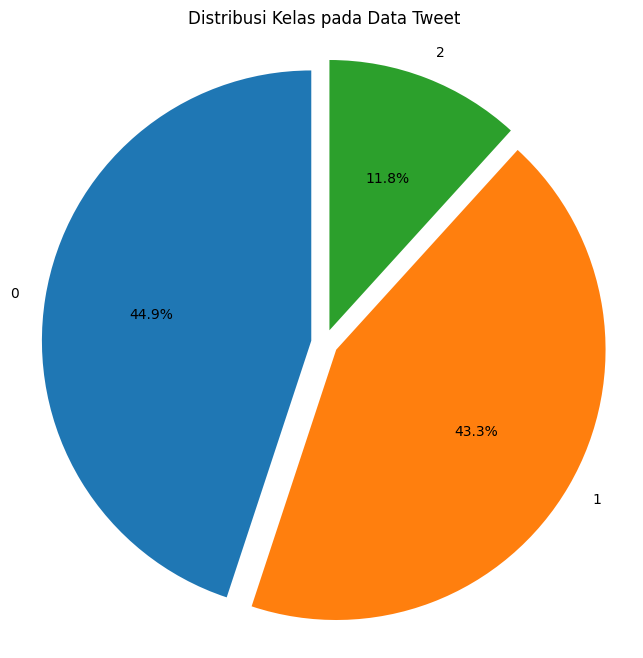

In [ ]:
# Membuat visualisasi distribusi kelas menggunakan pie chart

class_distribution = y_train_count['labels'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.1f%%', startangle=90, explode=[0.05]*len(class_distribution))
plt.title('Distribusi Kelas pada Data Tweet')
plt.axis('equal')
plt.show()

# Feature Extraction

In [ ]:
# Ekstraksi fitur dengan Bag of Word (BoW)

# Count vectorizer n_gram (unigram)
cv_unigram = CountVectorizer(max_features=5000, ngram_range=(1,1), min_df=5, max_df=0.8)
X_train_cv_unigram = cv_unigram.fit_transform(X_train)
X_test_cv_unigram = cv_unigram.transform(X_test)

# Count vectorizer n_gram (bigram)
cv_bigram = CountVectorizer(max_features=5000, ngram_range=(2,2), min_df=5, max_df=0.8)
X_train_cv_bigram = cv_bigram.fit_transform(X_train)
X_test_cv_bigram = cv_bigram.transform(X_test)

# Count vectorizer n_gram (combine unigram + bigram)
cv_combine = CountVectorizer(max_features=5000, ngram_range=(1,2), min_df=5, max_df=0.8)
X_train_cv_combine = cv_combine.fit_transform(X_train)
X_test_cv_combine = cv_combine.transform(X_test)

print(f"Shape X_train_cv_unigram: {X_train_cv_unigram.shape}")
print(f"Shape X_train_cv_bigram: {X_train_cv_bigram.shape}")
print(f"Shape X_train_cv_combine: {X_train_cv_combine.shape}")

Shape X_train_cv_unigram: (4072, 1156)
Shape X_train_cv_bigram: (4072, 569)
Shape X_train_cv_combine: (4072, 1725)


In [ ]:
# Menampilkan fitur unigram
pd.DataFrame(X_train_cv_unigram.toarray(), columns=cv_unigram.get_feature_names_out())

,abc,abdi,abdul,abi,acah,acan,adaan,adipura,adjie,adu,...,wetan,wil,wilayah,wilujeng,wisata,wulu,yah,yani,yth,zona
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4067,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4068,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4069,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4070,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Menampilkan fitur unigram
pd.DataFrame(X_train_cv_bigram.toarray(), columns=cv_bigram.get_feature_names_out())

,acah amp,ah menasution,ahmad yani,air alir,air daerah,air hujan,air jam,air jl,air kocor,air lancar,...,urc pju,urc tegallega,urc ujungberung,veteran parkir,via damkar,via lampu,via tertib,via wa,warga bandung,warga buang
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4067,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4068,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4069,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4070,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Menampilkan fitur unigram
pd.DataFrame(X_train_cv_combine.toarray(), columns=cv_combine.get_feature_names_out())

,abc,abdi,abdul,abi,acah,acah amp,acan,adaan,adipura,adjie,...,wetan,wil,wilayah,wilujeng,wisata,wulu,yah,yani,yth,zona
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4067,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4068,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4069,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4070,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Ekstraksi fitur dengan TF-IDF

# TF-IDF n_gram (unigram)
tfidf_unigram = TfidfVectorizer(max_features=5000, min_df=10, max_df=0.8, ngram_range=(1, 1))
X_train_tfidf_unigram = tfidf_unigram.fit_transform(X_train)
X_test_tfidf_unigram = tfidf_unigram.transform(X_test)

# TF-IDF n_gram (bigram)
tfidf_bigram = TfidfVectorizer(max_features=5000, min_df=10, max_df=0.8, ngram_range=(2, 2))
X_train_tfidf_bigram = tfidf_bigram.fit_transform(X_train)
X_test_tfidf_bigram = tfidf_bigram.transform(X_test)

# TF-IDF n_gram (combine unigram + bigram)
tfidf_combine = TfidfVectorizer(max_features=5000, min_df=10, max_df=0.8, ngram_range=(1, 2))
X_train_tfidf_combine = tfidf_combine.fit_transform(X_train)
X_test_tfidf_combine = tfidf_combine.transform(X_test)

print(f"Shape X_train_tfidf_unigram: {X_train_tfidf_unigram.shape}")
print(f"Shape X_train_tfidf_bigram: {X_train_tfidf_bigram.shape}")
print(f"Shape X_train_tfidf_combine: {X_train_tfidf_combine.shape}")

Shape X_train_tfidf_unigram: (4072, 592)
Shape X_train_tfidf_bigram: (4072, 176)
Shape X_train_tfidf_combine: (4072, 768)


In [ ]:
# Menampilkan fitur unigram
pd.DataFrame(X_train_tfidf_unigram.toarray(), columns=tfidf_unigram.get_feature_names_out())

,abdi,abi,acah,acan,adjie,adu,aduh,afrika,agung,ah,...,wajah,wajib,wali,walikota,warga,wastukencana,wilayah,yah,yani,yth
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4067,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4068,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4069,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Menampilkan fitur bigram
pd.DataFrame(X_train_tfidf_bigram.toarray(), columns=tfidf_bigram.get_feature_names_out())

,ah menasution,air alir,air pdam,alir air,amp jl,angkot tem,asia afrika,aya nu,babakan sari,badan jalan,...,trotoar jlremartadinata,urc bojonagara,urc cibeunying,urc gedebage,urc karees,urc pju,urc tegallega,urc ujungberung,via wa,warga buang
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4067,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.504676,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4068,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4069,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Menampilkan fitur bigram
pd.DataFrame(X_train_tfidf_combine.toarray(), columns=tfidf_combine.get_feature_names_out())

,abdi,abi,acah,acan,adjie,adu,aduh,afrika,agung,ah,...,wajib,wali,walikota,warga,warga buang,wastukencana,wilayah,yah,yani,yth
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4067,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4068,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4069,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Ekstraksi fitur dengan Word Embedding
X_train_tokens_embedding = [word_tokenize(text) for text in X_train]
X_test_tokens_embedding = [word_tokenize(text) for text in X_test]

w2v_model = Word2Vec(sentences=X_train_tokens_embedding, vector_size=100, window=5, min_count=5, epochs=100, seed=42)

In [ ]:
# Inspeksi model
print("Ukuran vocabulary:", len(w2v_model.wv))
print("Dimensi vektor   :", w2v_model.vector_size)

print("\nVektor kata 'banjir':", w2v_model.wv['banjir'][:5])

Ukuran vocabulary: 1178
Dimensi vektor   : 100

Vektor kata 'banjir': [ 3.2238467  -0.9282921  -0.75743115  0.10890206  1.2392683 ]


In [ ]:
# Cek similarity antar kata
print("\nKata mirip dengan 'banjir':")
print(w2v_model.wv.most_similar('banjir', topn=5))


Kata mirip dengan 'banjir':
[('genang', 0.6258779764175415), ('astanaanyar', 0.4998703598976135), ('deras', 0.49593397974967957), ('surut', 0.4891866147518158), ('katak', 0.47330355644226074)]


In [ ]:
# Ekstraksi fitur (melakukan transform hasil model menjadi fitur train & test) menggunakan mean pooling
def document_vector(doc_tokens, model, vector_size=100):

  vectors = []
  for word in doc_tokens:
    if word in model.wv: # hanya kata yang ada di vocabulary
      vectors.append(model.wv[word])

  if vectors:
    return np.mean(vectors, axis=0) # rata-rata semua vektor kata (mean pooling)
  else:
    return np.zeros(vector_size)

X_train_embedding = np.array([document_vector(tokens, w2v_model) for tokens in X_train_tokens_embedding])
X_test_embedding  = np.array([document_vector(tokens, w2v_model) for tokens in X_test_tokens_embedding])

print("\nShape X_train:", X_train_embedding.shape)
print("Shape X_test :", X_test_embedding.shape)


Shape X_train: (4072, 100)
Shape X_test : (1019, 100)


In [ ]:
pd.DataFrame(X_train_embedding)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.391013,-0.518961,-0.411364,-0.605762,-1.233010,0.360930,0.164048,0.517209,-0.598873,-0.555559,...,-0.807133,0.793373,-0.071208,-1.675120,0.183815,0.418677,-0.076436,0.144917,0.277068,1.158570
1,0.166725,-1.280420,0.007980,-0.616386,-0.441849,0.614962,-0.752792,-0.114427,-0.296002,0.287346,...,-0.653194,0.462751,0.788624,-0.625608,-0.472155,-0.527828,-0.329822,-0.015396,-0.153362,0.664115
2,-0.209816,-0.587873,-0.393755,0.216387,0.950390,-0.127484,-0.291358,-0.313990,-0.667119,0.540741,...,-0.387654,-0.247363,-0.619400,-0.440277,0.036373,-0.418341,0.316754,-0.246134,-0.261625,1.121685
3,-0.151839,-0.037243,0.176798,-0.232056,-0.540226,-0.081408,0.023764,0.360847,-0.297404,-0.617068,...,-0.654601,-0.480501,-0.346882,0.175262,0.329579,-0.343510,0.390131,0.205567,0.595242,-0.417904
4,-0.539937,-0.236092,-0.091212,-0.556875,-0.056757,0.490627,0.078063,0.465476,-0.035095,0.203511,...,-0.394668,0.235079,0.041094,0.305407,0.091435,0.037892,-0.021809,0.215116,-0.252875,0.627231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4067,-0.405017,-0.212840,-0.304968,-0.447329,0.073125,0.132517,0.438829,0.334036,-0.311715,0.728542,...,0.016879,0.759276,0.370569,0.152770,-0.383293,0.028207,0.175807,0.209728,-0.368728,0.896459
4068,0.495029,0.524419,-0.042421,0.096856,-0.749994,0.273479,-0.052585,0.347211,0.179173,0.245026,...,0.498391,-0.081541,-0.163059,0.496480,0.320487,-0.443758,0.603813,0.127651,-0.018554,-0.020988
4069,0.165116,-0.403675,-0.132311,-0.276837,-0.322483,-0.103776,0.004781,0.275582,0.008580,-0.215331,...,-0.435148,0.315564,-0.088603,-0.171884,0.307709,0.207030,-0.167713,0.345111,-0.265154,-0.185234
4070,-0.298299,-0.211613,-0.341602,0.090642,-0.640981,-0.249090,-0.275095,0.564080,-0.458395,0.029916,...,-0.908997,-0.192648,-0.459708,-0.560453,0.422125,0.487181,-0.461411,0.588910,-0.870825,0.074914


# Modelling Machine Learning

### Pemodelan dengan SVM

In [ ]:
# Training model Count Vectorizer unigram
svm_model_cv_unigram = LinearSVC(C=1.0).fit(X_train_cv_unigram, y_train)

# Training model Count Vectorizer bigram
svm_model_cv_bigram = LinearSVC(C=1.0).fit(X_train_cv_bigram, y_train)

# Training model Count Vectorizer combine
svm_model_cv_combine = LinearSVC(C=1.0).fit(X_train_cv_combine, y_train)

# Training model tfidf unigram
svm_model_tfidf_unigram = LinearSVC(C=1.0).fit(X_train_tfidf_unigram, y_train)

# Training model tfidf bigram
svm_model_tfidf_bigram = LinearSVC(C=1.0).fit(X_train_tfidf_bigram, y_train)

# Training model tfidf combine
svm_model_tfidf_combine = LinearSVC(C=1.0).fit(X_train_tfidf_combine, y_train)

# Training model word embedding
svm_model_word_embedding = LinearSVC(C=1.0).fit(X_train_embedding, y_train)

### Pemodelan dengan Naive Bayes

In [ ]:
# Training model Count Vectorizer unigram
nb_model_cv_unigram = MultinomialNB().fit(X_train_cv_unigram, y_train)

# Training model Count Vectorizer bigram
nb_model_cv_bigram = MultinomialNB().fit(X_train_cv_bigram, y_train)

# Training model Count Vectorizer combine
nb_model_cv_combine = MultinomialNB().fit(X_train_cv_combine, y_train)

# Training model tfidf unigram
nb_model_tfidf_unigram = MultinomialNB().fit(X_train_tfidf_unigram, y_train)

# Training model tfidf bigram
nb_model_tfidf_bigram = MultinomialNB().fit(X_train_tfidf_bigram, y_train)

# Training model tfidf bigram
nb_model_tfidf_combine = MultinomialNB().fit(X_train_tfidf_combine, y_train)

# Training model word embedding (pakai GaussianNB, bukan MultinomialNB)
nb_model_word_embedding = GaussianNB().fit(X_train_embedding, y_train)

### Pemodelan Dengan Logistic Regression

In [ ]:
# Training model Count Vectorizer unigram
lr_model_cv_unigram = LogisticRegression(C=4, penalty='l1', solver='liblinear').fit(X_train_cv_unigram, y_train)

# Training model Count Vectorizer bigram
lr_model_cv_bigram = LogisticRegression(C=4, penalty='l1', solver='liblinear').fit(X_train_cv_bigram, y_train)

# Training model Count Vectorizer bigram
lr_model_cv_combine = LogisticRegression(C=4, penalty='l1', solver='liblinear').fit(X_train_cv_combine, y_train)

# Training model tfidf unigram
lr_model_tfidf_unigram = LogisticRegression(C=4, penalty='l1', solver='liblinear').fit(X_train_tfidf_unigram, y_train)

# Training model tfidf bigram
lr_model_tfidf_bigram = LogisticRegression(C=4, penalty='l1', solver='liblinear').fit(X_train_tfidf_bigram, y_train)

# Training model tfidf bigram
lr_model_tfidf_combine = LogisticRegression(C=4, penalty='l1', solver='liblinear').fit(X_train_tfidf_combine, y_train)

# Training model word embedding
lr_model_word_embedding = LogisticRegression(C=4, penalty='l1', solver='liblinear').fit(X_train_embedding, y_train)

### Pemodelan dengan KNN

In [ ]:
# Training model Count Vectorizer unigram
knn_model_cv_unigram = KNeighborsClassifier(n_neighbors=5).fit(X_train_cv_unigram, y_train)

# Training model Count Vectorizer bigram
knn_model_cv_bigram = KNeighborsClassifier(n_neighbors=5).fit(X_train_cv_bigram, y_train)

# Training model Count Vectorizer combine
knn_model_cv_combine = KNeighborsClassifier(n_neighbors=5).fit(X_train_cv_combine, y_train)

# Training model tfidf unigram
knn_model_tfidf_unigram = KNeighborsClassifier(n_neighbors=5).fit(X_train_tfidf_unigram, y_train)

# Training model tfidf bigram
knn_model_tfidf_bigram = KNeighborsClassifier(n_neighbors=5).fit(X_train_tfidf_bigram, y_train)

# Training model tfidf combine
knn_model_tfidf_combine = KNeighborsClassifier(n_neighbors=5).fit(X_train_tfidf_combine, y_train)

# Training model word embedding
knn_model_word_embedding = KNeighborsClassifier(n_neighbors=5).fit(X_train_embedding, y_train)

### Pemodelan dengan Random Forest

In [ ]:
# Training model Count Vectorizer unigram
rf_model_cv_unigram = RandomForestClassifier(n_estimators=500).fit(X_train_cv_unigram, y_train)

# Training model Count Vectorizer bigram
rf_model_cv_bigram = RandomForestClassifier(n_estimators=500).fit(X_train_cv_bigram, y_train)

# Training model Count Vectorizer bigram
rf_model_cv_combine = RandomForestClassifier(n_estimators=500).fit(X_train_cv_combine, y_train)

# Training model tfidf unigram
rf_model_tfidf_unigram = RandomForestClassifier(n_estimators=500).fit(X_train_tfidf_unigram, y_train)

# Training model tfidf bigram
rf_model_tfidf_bigram = RandomForestClassifier(n_estimators=500).fit(X_train_tfidf_bigram, y_train)

# Training model tfidf bigram
rf_model_tfidf_combine = RandomForestClassifier(n_estimators=500).fit(X_train_tfidf_combine, y_train)

# Training model word embedding
rf_model_word_embedding = RandomForestClassifier(n_estimators=500).fit(X_train_embedding, y_train)

# Evaluasi

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    return {
        'accuracy_train': accuracy_score(y_train, y_pred_train),
        'accuracy_test': accuracy_score(y_test, y_pred_test),
        'precision': precision_score(y_test, y_pred_test, average='weighted'),
        'recall': recall_score(y_test, y_pred_test, average='weighted'),
        'f1_score': f1_score(y_test, y_pred_test, average='weighted')
    }

In [ ]:
results = {
    # SVM
    'SVM CV Unigram': evaluate_model(svm_model_cv_unigram, X_train_cv_unigram, y_train, X_test_cv_unigram, y_test),
    'SVM CV Bigram': evaluate_model(svm_model_cv_bigram, X_train_cv_bigram, y_train, X_test_cv_bigram, y_test),
    'SVM CV Combine': evaluate_model(svm_model_cv_combine, X_train_cv_combine, y_train, X_test_cv_combine, y_test),
    'SVM TFIDF Unigram': evaluate_model(svm_model_tfidf_unigram, X_train_tfidf_unigram, y_train, X_test_tfidf_unigram, y_test),
    'SVM TFIDF Bigram': evaluate_model(svm_model_tfidf_bigram, X_train_tfidf_bigram, y_train, X_test_tfidf_bigram, y_test),
    'SVM TFIDF Combine': evaluate_model(svm_model_tfidf_combine, X_train_tfidf_combine, y_train, X_test_tfidf_combine, y_test),
    'SVM Word Embedding': evaluate_model(svm_model_word_embedding, X_train_embedding, y_train, X_test_embedding, y_test),

    # Naive Bayes
    'NB CV Unigram': evaluate_model(nb_model_cv_unigram, X_train_cv_unigram, y_train, X_test_cv_unigram, y_test),
    'NB CV Bigram': evaluate_model(nb_model_cv_bigram, X_train_cv_bigram, y_train, X_test_cv_bigram, y_test),
    'NB CV Combine': evaluate_model(nb_model_cv_combine, X_train_cv_combine, y_train, X_test_cv_combine, y_test),
    'NB TFIDF Unigram': evaluate_model(nb_model_tfidf_unigram, X_train_tfidf_unigram, y_train, X_test_tfidf_unigram, y_test),
    'NB TFIDF Bigram': evaluate_model(nb_model_tfidf_bigram, X_train_tfidf_bigram, y_train, X_test_tfidf_bigram, y_test),
    'NB TFIDF Combine': evaluate_model(nb_model_tfidf_combine, X_train_tfidf_combine, y_train, X_test_tfidf_combine, y_test),
    'NB Word Embedding': evaluate_model(nb_model_word_embedding, X_train_embedding, y_train, X_test_embedding, y_test),

    # Logistic Regression
    'LR CV Unigram': evaluate_model(lr_model_cv_unigram, X_train_cv_unigram, y_train, X_test_cv_unigram, y_test),
    'LR CV Bigram': evaluate_model(lr_model_cv_bigram, X_train_cv_bigram, y_train, X_test_cv_bigram, y_test),
    'LR CV Combine': evaluate_model(lr_model_cv_combine, X_train_cv_combine, y_train, X_test_cv_combine, y_test),
    'LR TFIDF Unigram': evaluate_model(lr_model_tfidf_unigram, X_train_tfidf_unigram, y_train, X_test_tfidf_unigram, y_test),
    'LR TFIDF Bigram': evaluate_model(lr_model_tfidf_bigram, X_train_tfidf_bigram, y_train, X_test_tfidf_bigram, y_test),
    'LR TFIDF Combine': evaluate_model(lr_model_tfidf_combine, X_train_tfidf_combine, y_train, X_test_tfidf_combine, y_test),
    'LR Word Embedding': evaluate_model(lr_model_word_embedding, X_train_embedding, y_train, X_test_embedding, y_test),

    # Random Forest
    'RF CV Unigram': evaluate_model(rf_model_cv_unigram, X_train_cv_unigram, y_train, X_test_cv_unigram, y_test),
    'RF CV Bigram': evaluate_model(rf_model_cv_bigram, X_train_cv_bigram, y_train, X_test_cv_bigram, y_test),
    'RF CV Combine': evaluate_model(rf_model_cv_combine, X_train_cv_combine, y_train, X_test_cv_combine, y_test),
    'RF TFIDF Unigram': evaluate_model(rf_model_tfidf_unigram, X_train_tfidf_unigram, y_train, X_test_tfidf_unigram, y_test),
    'RF TFIDF Bigram': evaluate_model(rf_model_tfidf_bigram, X_train_tfidf_bigram, y_train, X_test_tfidf_bigram, y_test),
    'RF TFIDF Combine': evaluate_model(rf_model_tfidf_combine, X_train_tfidf_combine, y_train, X_test_tfidf_combine, y_test),
    'RF Word Embedding': evaluate_model(rf_model_word_embedding, X_train_embedding, y_train, X_test_embedding, y_test),

    # KNN
    'KNN CV Unigram': evaluate_model(knn_model_cv_unigram, X_train_cv_unigram, y_train, X_test_cv_unigram, y_test),
    'KNN CV Bigram': evaluate_model(knn_model_cv_bigram, X_train_cv_bigram, y_train, X_test_cv_bigram, y_test),
    'KNN CV Combine': evaluate_model(knn_model_cv_combine, X_train_cv_combine, y_train, X_test_cv_combine, y_test),
    'KNN TFIDF Unigram': evaluate_model(knn_model_tfidf_unigram, X_train_tfidf_unigram, y_train, X_test_tfidf_unigram, y_test),
    'KNN TFIDF Bigram': evaluate_model(knn_model_tfidf_bigram, X_train_tfidf_bigram, y_train, X_test_tfidf_bigram, y_test),
    'KNN TFIDF Combine': evaluate_model(knn_model_tfidf_combine, X_train_tfidf_combine, y_train, X_test_tfidf_combine, y_test),
    'KNN Word Embedding': evaluate_model(knn_model_word_embedding, X_train_embedding, y_train, X_test_embedding, y_test),
}

In [ ]:
# Ubah jadi DataFrame yang rapi
results_df = pd.DataFrame(results).T  # .T supaya tiap model jadi baris
results_df = results_df.reset_index().rename(columns={'index': 'Model'})

print("Tabel Hasil Evaluasi Semua Model")
results_df

Tabel Hasil Evaluasi Semua Model


,Model,accuracy_train,accuracy_test,precision,recall,f1_score
0,SVM CV Unigram,0.937623,0.810599,0.811531,0.810599,0.810948
1,SVM CV Bigram,0.771857,0.685967,0.723133,0.685967,0.675730
2,SVM CV Combine,0.962672,0.802748,0.803431,0.802748,0.803010
3,SVM TFIDF Unigram,0.855354,0.787046,0.787596,0.787046,0.787285
4,SVM TFIDF Bigram,0.684921,0.627085,0.659702,0.627085,0.609714
5,SVM TFIDF Combine,0.871807,0.788027,0.789134,0.788027,0.788469
6,SVM Word Embedding,0.750737,0.702650,0.701747,0.702650,0.700976
7,NB CV Unigram,0.826130,0.755643,0.754779,0.755643,0.754350
8,NB CV Bigram,0.655206,0.628067,0.644561,0.628067,0.604875
9,NB CV Combine,0.834725,0.758587,0.757579,0.758587,0.757633


# Pemodelan Machine Learning dengan Data SMOTE

### Oversampling dengan SMOTE

In [ ]:
# SMOTE Count Vectorizer n_gram (unigram)
smote_cv_unigram = SMOTE(sampling_strategy={2: 1500}, random_state=42)
X_train_cv_unigram_smote, y_train_cv_unigram_smote = smote_cv_unigram.fit_resample(X_train_cv_unigram, y_train)

# Cek distribusi kelas sebelum dan sesudah SMOTE
print("Distribusi sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nDistribusi sesudah SMOTE:")
print(pd.Series(y_train_cv_unigram_smote).value_counts())

Distribusi sebelum SMOTE:
0    1829
1    1764
2     479
Name: count, dtype: int64

Distribusi sesudah SMOTE:
0    1829
1    1764
2    1500
Name: count, dtype: int64


In [ ]:
# SMOTE Count Vectorizer n_gram (bigram)
smote_cv_bigram = SMOTE(sampling_strategy={2: 1500}, random_state=42)
X_train_cv_bigram_smote, y_train_cv_bigram_smote = smote_cv_bigram.fit_resample(X_train_cv_bigram, y_train)

print("Distribusi sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nDistribusi sesudah SMOTE:")
print(pd.Series(y_train_cv_bigram_smote).value_counts())

Distribusi sebelum SMOTE:
0    1829
1    1764
2     479
Name: count, dtype: int64

Distribusi sesudah SMOTE:
0    1829
1    1764
2    1500
Name: count, dtype: int64


In [ ]:
# SMOTE Count Vectorizer n_gram (combine unigram + bigram)
smote_cv_combine = SMOTE(sampling_strategy={2: 1500}, random_state=42)
X_train_cv_combine_smote, y_train_cv_combine_smote = smote_cv_combine.fit_resample(X_train_cv_combine, y_train)

print("Distribusi sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nDistribusi sesudah SMOTE:")
print(pd.Series(y_train_cv_combine_smote).value_counts())

Distribusi sebelum SMOTE:
0    1829
1    1764
2     479
Name: count, dtype: int64

Distribusi sesudah SMOTE:
0    1829
1    1764
2    1500
Name: count, dtype: int64


In [ ]:
# SMOTE TF-IDF n_gram (unigram)
smote_tfidf_unigram = SMOTE(sampling_strategy={2: 1500}, random_state=42)
X_train_tfidf_unigram_smote, y_train_tfidf_unigram_smote = smote_tfidf_unigram.fit_resample(X_train_tfidf_unigram, y_train)

print("Distribusi sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nDistribusi sesudah SMOTE:")
print(pd.Series(y_train_tfidf_unigram_smote).value_counts())

Distribusi sebelum SMOTE:
0    1829
1    1764
2     479
Name: count, dtype: int64

Distribusi sesudah SMOTE:
0    1829
1    1764
2    1500
Name: count, dtype: int64


In [ ]:
# SMOTE TF-IDF n_gram (bigram)
smote_tfidf_bigram = SMOTE(sampling_strategy={2: 1500}, random_state=42)
X_train_tfidf_bigram_smote, y_train_tfidf_bigram_smote = smote_tfidf_bigram.fit_resample(X_train_tfidf_bigram, y_train)

print("Distribusi sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nDistribusi sesudah SMOTE:")
print(pd.Series(y_train_tfidf_bigram_smote).value_counts())

Distribusi sebelum SMOTE:
0    1829
1    1764
2     479
Name: count, dtype: int64

Distribusi sesudah SMOTE:
0    1829
1    1764
2    1500
Name: count, dtype: int64


In [ ]:
# SMOTE TF-IDF n_gram (combine unigram + bigram)
smote_tfidf_combine = SMOTE(sampling_strategy={2: 1500}, random_state=42)
X_train_tfidf_combine_smote, y_train_tfidf_combine_smote = smote_tfidf_combine.fit_resample(X_train_tfidf_combine, y_train)

print("Distribusi sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nDistribusi sesudah SMOTE:")
print(pd.Series(y_train_tfidf_combine_smote).value_counts())

Distribusi sebelum SMOTE:
0    1829
1    1764
2     479
Name: count, dtype: int64

Distribusi sesudah SMOTE:
0    1829
1    1764
2    1500
Name: count, dtype: int64


In [ ]:
# SMOTE Word Embedding (Word2Vec)
smote_embedding = SMOTE(sampling_strategy={2: 1500}, random_state=42)
X_train_embedding_smote, y_train_embedding_smote = smote_embedding.fit_resample(X_train_embedding, y_train)

print("Distribusi sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nDistribusi sesudah SMOTE:")
print(pd.Series(y_train_embedding_smote).value_counts())

Distribusi sebelum SMOTE:
0    1829
1    1764
2     479
Name: count, dtype: int64

Distribusi sesudah SMOTE:
0    1829
1    1764
2    1500
Name: count, dtype: int64


### Pemodelan dengan SVM (SMOTE)

In [ ]:
# Training model Count Vectorizer unigram
svm_model_cv_unigram_smote = LinearSVC(C=1.0).fit(X_train_cv_unigram_smote, y_train_cv_unigram_smote)

# Training model Count Vectorizer bigram
svm_model_cv_bigram_smote = LinearSVC(C=1.0).fit(X_train_cv_bigram_smote, y_train_cv_bigram_smote)

# Training model Count Vectorizer combine
svm_model_cv_combine_smote = LinearSVC(C=1.0).fit(X_train_cv_combine_smote, y_train_cv_combine_smote)

# Training model tfidf unigram
svm_model_tfidf_unigram_smote = LinearSVC(C=1.0).fit(X_train_tfidf_unigram_smote, y_train_tfidf_unigram_smote)

# Training model tfidf bigram
svm_model_tfidf_bigram_smote = LinearSVC(C=1.0).fit(X_train_tfidf_bigram_smote, y_train_tfidf_bigram_smote)

# Training model tfidf combine
svm_model_tfidf_combine_smote = LinearSVC(C=1.0).fit(X_train_tfidf_combine_smote, y_train_tfidf_combine_smote)

# Training model word embedding
svm_model_word_embedding_smote = LinearSVC(C=1.0).fit(X_train_embedding_smote, y_train_embedding_smote)

### Pemodelan dengan Naive Bayes (SMOTE)

In [ ]:
# Training model Count Vectorizer unigram
nb_model_cv_unigram_smote = MultinomialNB().fit(X_train_cv_unigram_smote, y_train_cv_unigram_smote)

# Training model Count Vectorizer bigram
nb_model_cv_bigram_smote = MultinomialNB().fit(X_train_cv_bigram_smote, y_train_cv_bigram_smote)

# Training model Count Vectorizer combine
nb_model_cv_combine_smote = MultinomialNB().fit(X_train_cv_combine_smote, y_train_cv_combine_smote)

# Training model tfidf unigram
nb_model_tfidf_unigram_smote = MultinomialNB().fit(X_train_tfidf_unigram_smote, y_train_tfidf_unigram_smote)

# Training model tfidf bigram
nb_model_tfidf_bigram_smote = MultinomialNB().fit(X_train_tfidf_bigram_smote, y_train_tfidf_bigram_smote)

# Training model tfidf combine
nb_model_tfidf_combine_smote = MultinomialNB().fit(X_train_tfidf_combine_smote, y_train_tfidf_combine_smote)

# Training model word embedding (pakai GaussianNB, bukan MultinomialNB)
nb_model_word_embedding_smote = GaussianNB().fit(X_train_embedding_smote, y_train_embedding_smote)

### Pemodelan Dengan Logistic Regression (SMOTE)

In [ ]:
# Training model Count Vectorizer unigram
lr_model_cv_unigram_smote = LogisticRegression(C=4, penalty='l1', solver='liblinear').fit(X_train_cv_unigram_smote, y_train_cv_unigram_smote)

# Training model Count Vectorizer bigram
lr_model_cv_bigram_smote = LogisticRegression(C=4, penalty='l1', solver='liblinear').fit(X_train_cv_bigram_smote, y_train_cv_bigram_smote)

# Training model Count Vectorizer combine
lr_model_cv_combine_smote = LogisticRegression(C=4, penalty='l1', solver='liblinear').fit(X_train_cv_combine_smote, y_train_cv_combine_smote)

# Training model tfidf unigram
lr_model_tfidf_unigram_smote = LogisticRegression(C=4, penalty='l1', solver='liblinear').fit(X_train_tfidf_unigram_smote, y_train_tfidf_unigram_smote)

# Training model tfidf bigram
lr_model_tfidf_bigram_smote = LogisticRegression(C=4, penalty='l1', solver='liblinear').fit(X_train_tfidf_bigram_smote, y_train_tfidf_bigram_smote)

# Training model tfidf combine
lr_model_tfidf_combine_smote = LogisticRegression(C=4, penalty='l1', solver='liblinear').fit(X_train_tfidf_combine_smote, y_train_tfidf_combine_smote)

# Training model word embedding
lr_model_word_embedding_smote = LogisticRegression(C=4, penalty='l1', solver='liblinear').fit(X_train_embedding_smote, y_train_embedding_smote)

### Pemodelan dengan KNN (SMOTE)

In [ ]:
# Training model Count Vectorizer unigram
knn_model_cv_unigram_smote = KNeighborsClassifier(n_neighbors=5).fit(X_train_cv_unigram_smote, y_train_cv_unigram_smote)

# Training model Count Vectorizer bigram
knn_model_cv_bigram_smote = KNeighborsClassifier(n_neighbors=5).fit(X_train_cv_bigram_smote, y_train_cv_bigram_smote)

# Training model Count Vectorizer combine
knn_model_cv_combine_smote = KNeighborsClassifier(n_neighbors=5).fit(X_train_cv_combine_smote, y_train_cv_combine_smote)

# Training model tfidf unigram
knn_model_tfidf_unigram_smote = KNeighborsClassifier(n_neighbors=5).fit(X_train_tfidf_unigram_smote, y_train_tfidf_unigram_smote)

# Training model tfidf bigram
knn_model_tfidf_bigram_smote = KNeighborsClassifier(n_neighbors=5).fit(X_train_tfidf_bigram_smote, y_train_tfidf_bigram_smote)

# Training model tfidf combine
knn_model_tfidf_combine_smote = KNeighborsClassifier(n_neighbors=5).fit(X_train_tfidf_combine_smote, y_train_tfidf_combine_smote)

# Training model word embedding
knn_model_word_embedding_smote = KNeighborsClassifier(n_neighbors=5).fit(X_train_embedding_smote, y_train_embedding_smote)

### Pemodelan dengan Random Forest (SMOTE)

In [ ]:
# Training model Count Vectorizer unigram
rf_model_cv_unigram_smote = RandomForestClassifier(n_estimators=500).fit(X_train_cv_unigram_smote, y_train_cv_unigram_smote)

# Training model Count Vectorizer bigram
rf_model_cv_bigram_smote = RandomForestClassifier(n_estimators=500).fit(X_train_cv_bigram_smote, y_train_cv_bigram_smote)

# Training model Count Vectorizer combine
rf_model_cv_combine_smote = RandomForestClassifier(n_estimators=500).fit(X_train_cv_combine_smote, y_train_cv_combine_smote)

# Training model tfidf unigram
rf_model_tfidf_unigram_smote = RandomForestClassifier(n_estimators=500).fit(X_train_tfidf_unigram_smote, y_train_tfidf_unigram_smote)

# Training model tfidf bigram
rf_model_tfidf_bigram_smote = RandomForestClassifier(n_estimators=500).fit(X_train_tfidf_bigram_smote, y_train_tfidf_bigram_smote)

# Training model tfidf combine
rf_model_tfidf_combine_smote = RandomForestClassifier(n_estimators=500).fit(X_train_tfidf_combine_smote, y_train_tfidf_combine_smote)

# Training model word embedding
rf_model_word_embedding_smote = RandomForestClassifier(n_estimators=500).fit(X_train_embedding_smote, y_train_embedding_smote)

# Evaluasi data SMOTE

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    return {
        'accuracy_train': accuracy_score(y_train, y_pred_train),
        'accuracy_test': accuracy_score(y_test, y_pred_test),
        'precision': precision_score(y_test, y_pred_test, average='weighted'),
        'recall': recall_score(y_test, y_pred_test, average='weighted'),
        'f1_score': f1_score(y_test, y_pred_test, average='weighted')
    }

In [ ]:
results_smote = {
    # SVM (SMOTE)
    'SVM CV Unigram SMOTE': evaluate_model(svm_model_cv_unigram_smote, X_train_cv_unigram_smote, y_train_cv_unigram_smote, X_test_cv_unigram, y_test),
    'SVM CV Bigram SMOTE': evaluate_model(svm_model_cv_bigram_smote, X_train_cv_bigram_smote, y_train_cv_bigram_smote, X_test_cv_bigram, y_test),
    'SVM CV Combine SMOTE': evaluate_model(svm_model_cv_combine_smote, X_train_cv_combine_smote, y_train_cv_combine_smote, X_test_cv_combine, y_test),
    'SVM TFIDF Unigram SMOTE': evaluate_model(svm_model_tfidf_unigram_smote, X_train_tfidf_unigram_smote, y_train_tfidf_unigram_smote, X_test_tfidf_unigram, y_test),
    'SVM TFIDF Bigram SMOTE': evaluate_model(svm_model_tfidf_bigram_smote, X_train_tfidf_bigram_smote, y_train_tfidf_bigram_smote, X_test_tfidf_bigram, y_test),
    'SVM TFIDF Combine SMOTE': evaluate_model(svm_model_tfidf_combine_smote, X_train_tfidf_combine_smote, y_train_tfidf_combine_smote, X_test_tfidf_combine, y_test),
    'SVM Word Embedding SMOTE': evaluate_model(svm_model_word_embedding_smote, X_train_embedding_smote, y_train_embedding_smote, X_test_embedding, y_test),

    # Naive Bayes (SMOTE)
    'NB CV Unigram SMOTE': evaluate_model(nb_model_cv_unigram_smote, X_train_cv_unigram_smote, y_train_cv_unigram_smote, X_test_cv_unigram, y_test),
    'NB CV Bigram SMOTE': evaluate_model(nb_model_cv_bigram_smote, X_train_cv_bigram_smote, y_train_cv_bigram_smote, X_test_cv_bigram, y_test),
    'NB CV Combine SMOTE': evaluate_model(nb_model_cv_combine_smote, X_train_cv_combine_smote, y_train_cv_combine_smote, X_test_cv_combine, y_test),
    'NB TFIDF Unigram SMOTE': evaluate_model(nb_model_tfidf_unigram_smote, X_train_tfidf_unigram_smote, y_train_tfidf_unigram_smote, X_test_tfidf_unigram, y_test),
    'NB TFIDF Bigram SMOTE': evaluate_model(nb_model_tfidf_bigram_smote, X_train_tfidf_bigram_smote, y_train_tfidf_bigram_smote, X_test_tfidf_bigram, y_test),
    'NB TFIDF Combine SMOTE': evaluate_model(nb_model_tfidf_combine_smote, X_train_tfidf_combine_smote, y_train_tfidf_combine_smote, X_test_tfidf_combine, y_test),
    'NB Word Embedding SMOTE': evaluate_model(nb_model_word_embedding_smote, X_train_embedding_smote, y_train_embedding_smote, X_test_embedding, y_test),

    # Logistic Regression (SMOTE)
    'LR CV Unigram SMOTE': evaluate_model(lr_model_cv_unigram_smote, X_train_cv_unigram_smote, y_train_cv_unigram_smote, X_test_cv_unigram, y_test),
    'LR CV Bigram SMOTE': evaluate_model(lr_model_cv_bigram_smote, X_train_cv_bigram_smote, y_train_cv_bigram_smote, X_test_cv_bigram, y_test),
    'LR CV Combine SMOTE': evaluate_model(lr_model_cv_combine_smote, X_train_cv_combine_smote, y_train_cv_combine_smote, X_test_cv_combine, y_test),
    'LR TFIDF Unigram SMOTE': evaluate_model(lr_model_tfidf_unigram_smote, X_train_tfidf_unigram_smote, y_train_tfidf_unigram_smote, X_test_tfidf_unigram, y_test),
    'LR TFIDF Bigram SMOTE': evaluate_model(lr_model_tfidf_bigram_smote, X_train_tfidf_bigram_smote, y_train_tfidf_bigram_smote, X_test_tfidf_bigram, y_test),
    'LR TFIDF Combine SMOTE': evaluate_model(lr_model_tfidf_combine_smote, X_train_tfidf_combine_smote, y_train_tfidf_combine_smote, X_test_tfidf_combine, y_test),
    'LR Word Embedding SMOTE': evaluate_model(lr_model_word_embedding_smote, X_train_embedding_smote, y_train_embedding_smote, X_test_embedding, y_test),

    # Random Forest (SMOTE)
    'RF CV Unigram SMOTE': evaluate_model(rf_model_cv_unigram_smote, X_train_cv_unigram_smote, y_train_cv_unigram_smote, X_test_cv_unigram, y_test),
    'RF CV Bigram SMOTE': evaluate_model(rf_model_cv_bigram_smote, X_train_cv_bigram_smote, y_train_cv_bigram_smote, X_test_cv_bigram, y_test),
    'RF CV Combine SMOTE': evaluate_model(rf_model_cv_combine_smote, X_train_cv_combine_smote, y_train_cv_combine_smote, X_test_cv_combine, y_test),
    'RF TFIDF Unigram SMOTE': evaluate_model(rf_model_tfidf_unigram_smote, X_train_tfidf_unigram_smote, y_train_tfidf_unigram_smote, X_test_tfidf_unigram, y_test),
    'RF TFIDF Bigram SMOTE': evaluate_model(rf_model_tfidf_bigram_smote, X_train_tfidf_bigram_smote, y_train_tfidf_bigram_smote, X_test_tfidf_bigram, y_test),
    'RF TFIDF Combine SMOTE': evaluate_model(rf_model_tfidf_combine_smote, X_train_tfidf_combine_smote, y_train_tfidf_combine_smote, X_test_tfidf_combine, y_test),
    'RF Word Embedding SMOTE': evaluate_model(rf_model_word_embedding_smote, X_train_embedding_smote, y_train_embedding_smote, X_test_embedding, y_test),

    # KNN (SMOTE)
    'KNN CV Unigram SMOTE': evaluate_model(knn_model_cv_unigram_smote, X_train_cv_unigram_smote, y_train_cv_unigram_smote, X_test_cv_unigram, y_test),
    'KNN CV Bigram SMOTE': evaluate_model(knn_model_cv_bigram_smote, X_train_cv_bigram_smote, y_train_cv_bigram_smote, X_test_cv_bigram, y_test),
    'KNN CV Combine SMOTE': evaluate_model(knn_model_cv_combine_smote, X_train_cv_combine_smote, y_train_cv_combine_smote, X_test_cv_combine, y_test),
    'KNN TFIDF Unigram SMOTE': evaluate_model(knn_model_tfidf_unigram_smote, X_train_tfidf_unigram_smote, y_train_tfidf_unigram_smote, X_test_tfidf_unigram, y_test),
    'KNN TFIDF Bigram SMOTE': evaluate_model(knn_model_tfidf_bigram_smote, X_train_tfidf_bigram_smote, y_train_tfidf_bigram_smote, X_test_tfidf_bigram, y_test),
    'KNN TFIDF Combine SMOTE': evaluate_model(knn_model_tfidf_combine_smote, X_train_tfidf_combine_smote, y_train_tfidf_combine_smote, X_test_tfidf_combine, y_test),
    'KNN Word Embedding SMOTE': evaluate_model(knn_model_word_embedding_smote, X_train_embedding_smote, y_train_embedding_smote, X_test_embedding, y_test),
}

In [ ]:
print("Shape X_train_cv_unigram:", X_train_cv_unigram.shape)
print("Shape X_test_cv_unigram:", X_test_cv_unigram.shape)
print("Shape X_train_cv_combine:", X_train_cv_combine.shape)
print("Shape X_test_cv_combine:", X_test_cv_combine.shape)

Shape X_train_cv_unigram: (4072, 1156)
Shape X_test_cv_unigram: (1019, 1156)
Shape X_train_cv_combine: (4072, 1725)
Shape X_test_cv_combine: (1019, 1725)


In [ ]:
# Ubah jadi DataFrame yang rapi
results_smote_df = pd.DataFrame(results_smote).T  # .T supaya tiap model jadi baris
results_smote_df = results_smote_df.reset_index().rename(columns={'index': 'Model'})

print("Tabel Hasil Evaluasi Semua Model SMOTE")
results_smote_df

Tabel Hasil Evaluasi Semua Model SMOTE


,Model,accuracy_train,accuracy_test,precision,recall,f1_score
0,SVM CV Unigram SMOTE,0.939721,0.808636,0.808470,0.808636,0.808542
1,SVM CV Bigram SMOTE,0.798351,0.678116,0.713882,0.678116,0.667981
2,SVM CV Combine SMOTE,0.957000,0.798822,0.798728,0.798822,0.798744
3,SVM TFIDF Unigram SMOTE,0.884940,0.783121,0.783019,0.783121,0.783004
4,SVM TFIDF Bigram SMOTE,0.737286,0.625123,0.658094,0.625123,0.606966
5,SVM TFIDF Combine SMOTE,0.896132,0.788027,0.788072,0.788027,0.788031
6,SVM Word Embedding SMOTE,0.795405,0.706575,0.704390,0.706575,0.703762
7,NB CV Unigram SMOTE,0.850972,0.756624,0.755644,0.756624,0.755342
8,NB CV Bigram SMOTE,0.699980,0.625123,0.639742,0.625123,0.600481
9,NB CV Combine SMOTE,0.856273,0.758587,0.757566,0.758587,0.757677


### Visualisasi Hasil evaluasi

In [ ]:
# Pastikan results_smote_df pakai nama variabel sendiri (bukan menimpa results_df)
results_smote_df = pd.DataFrame(results_smote).T
results_smote_df = results_smote_df.reset_index().rename(columns={'index': 'Model'})

# Gabungkan kedua model untuk dijadikan label "dasar" tanpa suffix SMOTE
results_df_plot = results_df.copy()
results_df_plot['Tipe'] = 'Tanpa SMOTE'
results_df_plot['Model_Base'] = results_df_plot['Model']

results_smote_df_plot = results_smote_df.copy()
results_smote_df_plot['Tipe'] = 'Dengan SMOTE'
results_smote_df_plot['Model_Base'] = results_smote_df_plot['Model'].str.replace(' SMOTE', '', regex=False)

# Gabungkan keduanya
combined_df = pd.concat([results_df_plot, results_smote_df_plot], ignore_index=True)

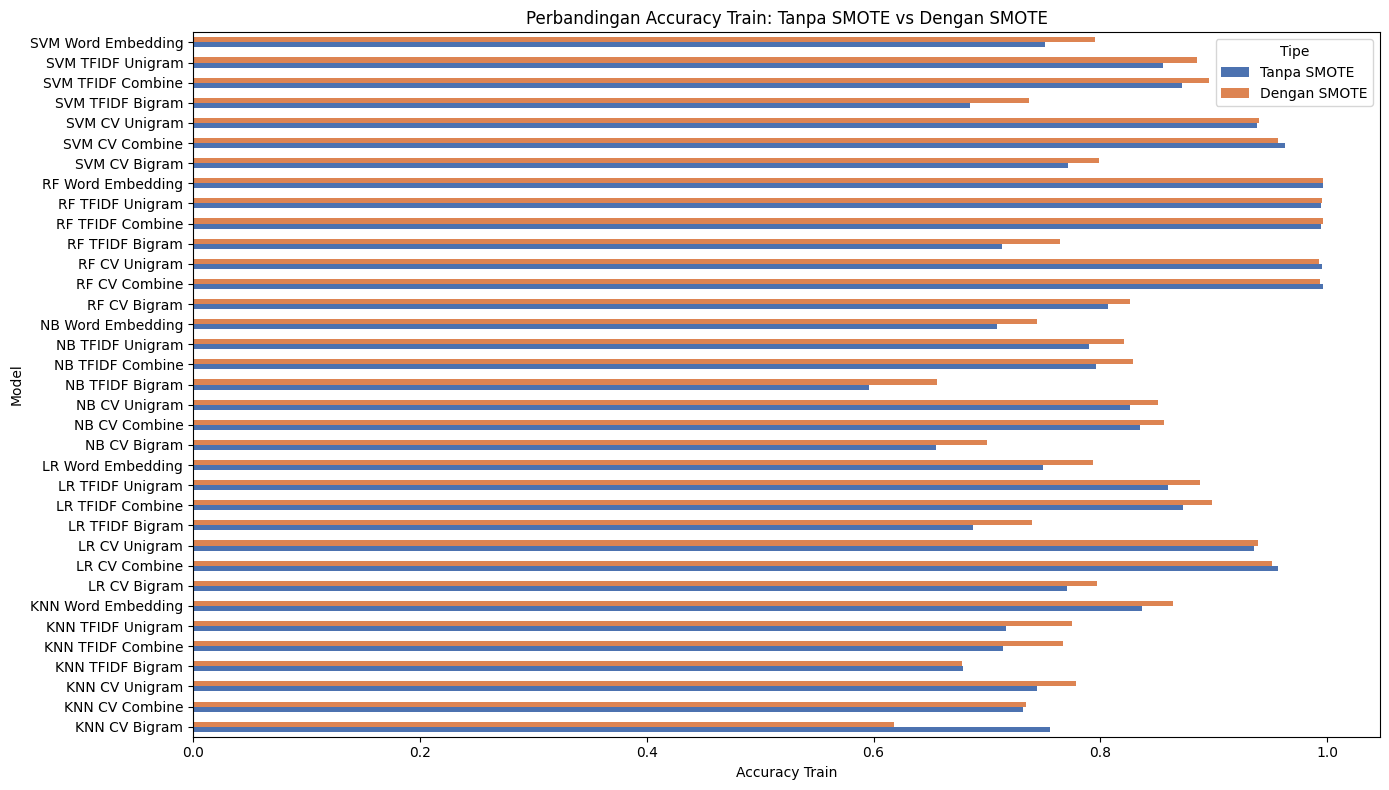

In [ ]:
# BAR CHART: Accuracy Train (Tanpa SMOTE vs Dengan SMOTE) =====
pivot_train = combined_df.pivot(index='Model_Base', columns='Tipe', values='accuracy_train')
pivot_train = pivot_train[['Tanpa SMOTE', 'Dengan SMOTE']]

fig, ax = plt.subplots(figsize=(14, 8))
pivot_train.plot(kind='barh', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xlabel('Accuracy Train')
ax.set_ylabel('Model')
ax.set_title('Perbandingan Accuracy Train: Tanpa SMOTE vs Dengan SMOTE')
ax.legend(title='Tipe')
plt.tight_layout()
plt.show()

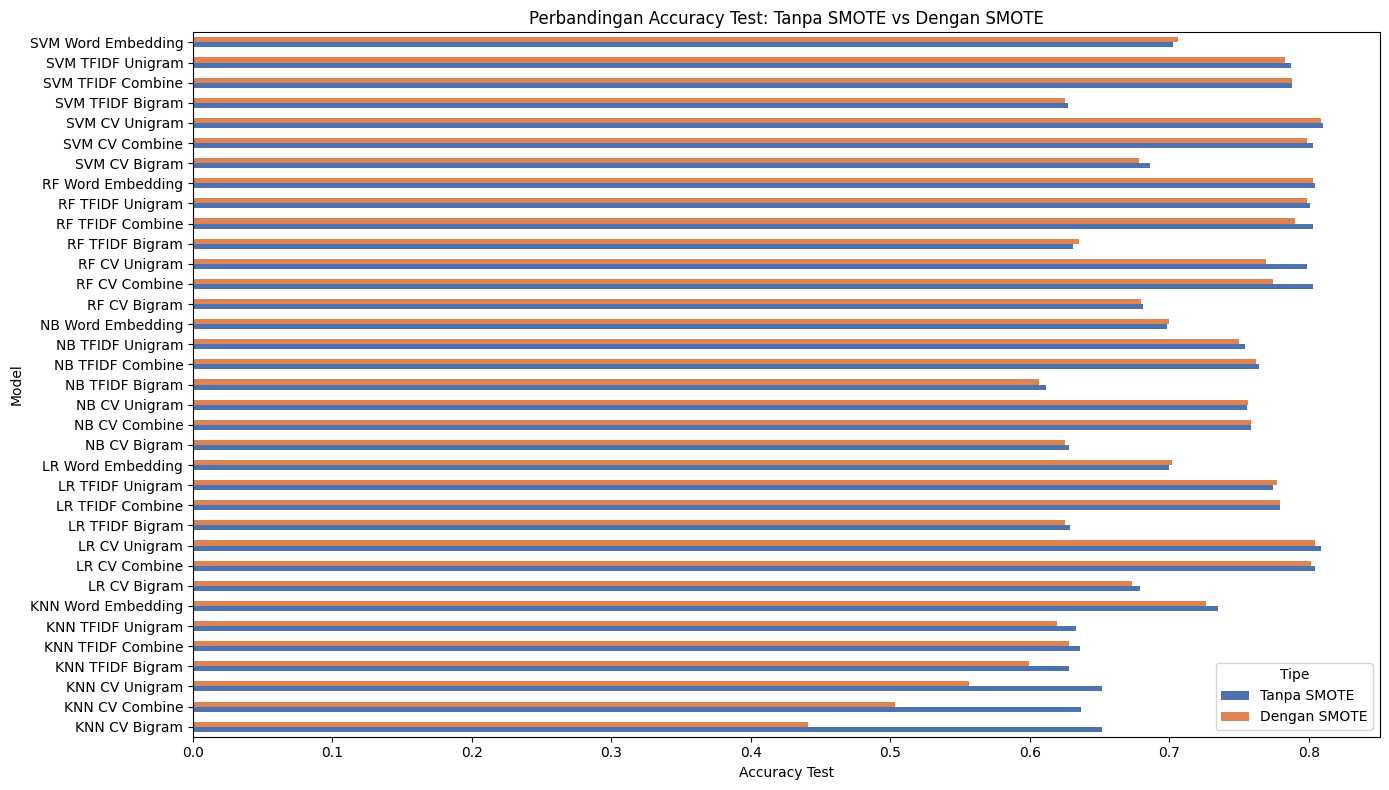

In [ ]:
# BAR CHART: Accuracy Test (Tanpa SMOTE vs Dengan SMOTE) =====
pivot_test = combined_df.pivot(index='Model_Base', columns='Tipe', values='accuracy_test')
pivot_test = pivot_test[['Tanpa SMOTE', 'Dengan SMOTE']]  # urutkan kolom

fig, ax = plt.subplots(figsize=(14, 8))
pivot_test.plot(kind='barh', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xlabel('Accuracy Test')
ax.set_ylabel('Model')
ax.set_title('Perbandingan Accuracy Test: Tanpa SMOTE vs Dengan SMOTE')
ax.legend(title='Tipe')
plt.tight_layout()
plt.show()

### Classification Report untuk 3 Model Terbaik

In [ ]:
target_names_original = encoder.inverse_transform(np.unique(y_train))

# SVM CV Unigram
print("Classification Report for SVM CV Unigram")

# Training Data
y_pred_train_svm_cv_unigram = svm_model_cv_unigram.predict(X_train_cv_unigram)
print("\nTraining Data")
print(classification_report(y_train, y_pred_train_svm_cv_unigram, target_names=target_names_original))

# Testing Data
y_pred_test_svm_cv_unigram = svm_model_cv_unigram.predict(X_test_cv_unigram)
print("\nTesting Data")
print(classification_report(y_test, y_pred_test_svm_cv_unigram, target_names=target_names_original))

Classification Report for SVM CV Unigram

Training Data
              precision    recall  f1-score   support

     Keluhan       0.94      0.93      0.94      1829
       NotKR       0.92      0.94      0.93      1764
      Respon       0.98      0.97      0.98       479

    accuracy                           0.94      4072
   macro avg       0.95      0.95      0.95      4072
weighted avg       0.94      0.94      0.94      4072


Testing Data
              precision    recall  f1-score   support

     Keluhan       0.81      0.80      0.80       458
       NotKR       0.78      0.80      0.79       441
      Respon       0.94      0.90      0.92       120

    accuracy                           0.81      1019
   macro avg       0.84      0.83      0.84      1019
weighted avg       0.81      0.81      0.81      1019



In [ ]:
# LR CV Unigram
print("Classification Report for LR CV Unigram")

# Training Data
y_pred_train_lr_cv_unigram = lr_model_cv_unigram.predict(X_train_cv_unigram)
print("\nTraining Data")
print(classification_report(y_train, y_pred_train_lr_cv_unigram, target_names=target_names_original))

# Testing Data
y_pred_test_lr_cv_unigram = lr_model_cv_unigram.predict(X_test_cv_unigram)
print("\nTesting Data")
print(classification_report(y_test, y_pred_test_lr_cv_unigram, target_names=target_names_original))

Classification Report for LR CV Unigram

Training Data
              precision    recall  f1-score   support

     Keluhan       0.94      0.93      0.93      1829
       NotKR       0.92      0.94      0.93      1764
      Respon       0.98      0.96      0.97       479

    accuracy                           0.94      4072
   macro avg       0.95      0.94      0.94      4072
weighted avg       0.94      0.94      0.94      4072


Testing Data
              precision    recall  f1-score   support

     Keluhan       0.80      0.81      0.80       458
       NotKR       0.78      0.79      0.79       441
      Respon       0.95      0.88      0.92       120

    accuracy                           0.81      1019
   macro avg       0.85      0.83      0.84      1019
weighted avg       0.81      0.81      0.81      1019



In [ ]:
# --- LR CV Combine ---
print("\nClassification Report for LR CV Combine")

# Training Data
y_pred_train_lr_cv_combine = lr_model_cv_combine.predict(X_train_cv_combine)
print("\nTraining Data")
print(classification_report(y_train, y_pred_train_lr_cv_combine, target_names=target_names_original))

# Testing Data
y_pred_test_lr_cv_combine = lr_model_cv_combine.predict(X_test_cv_combine)
print("\nTesting Data")
print(classification_report(y_test, y_pred_test_lr_cv_combine, target_names=target_names_original))


Classification Report for LR CV Combine

Training Data
              precision    recall  f1-score   support

     Keluhan       0.96      0.95      0.95      1829
       NotKR       0.94      0.96      0.95      1764
      Respon       0.99      0.97      0.98       479

    accuracy                           0.96      4072
   macro avg       0.96      0.96      0.96      4072
weighted avg       0.96      0.96      0.96      4072


Testing Data
              precision    recall  f1-score   support

     Keluhan       0.80      0.81      0.80       458
       NotKR       0.78      0.78      0.78       441
      Respon       0.95      0.89      0.92       120

    accuracy                           0.80      1019
   macro avg       0.84      0.83      0.83      1019
weighted avg       0.81      0.80      0.81      1019



# Kesimpulan

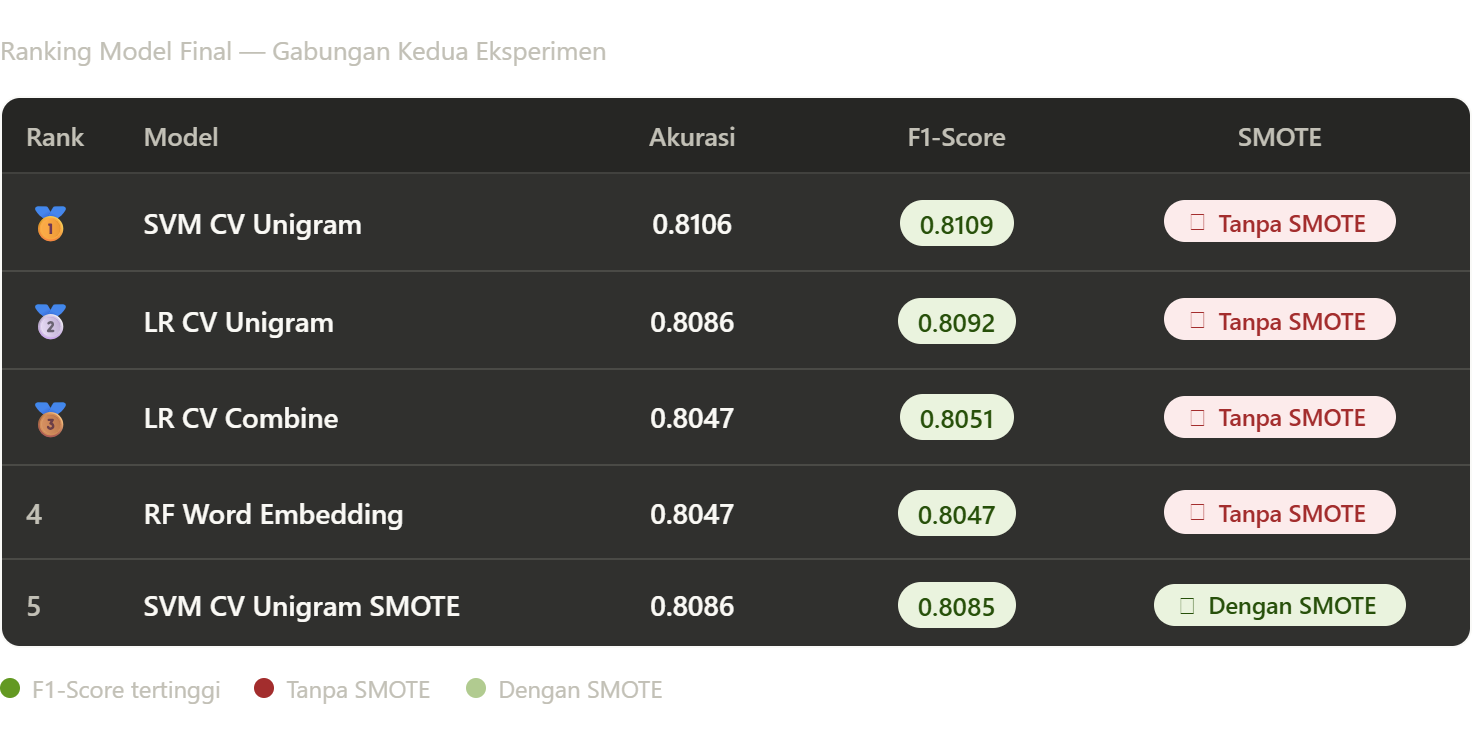

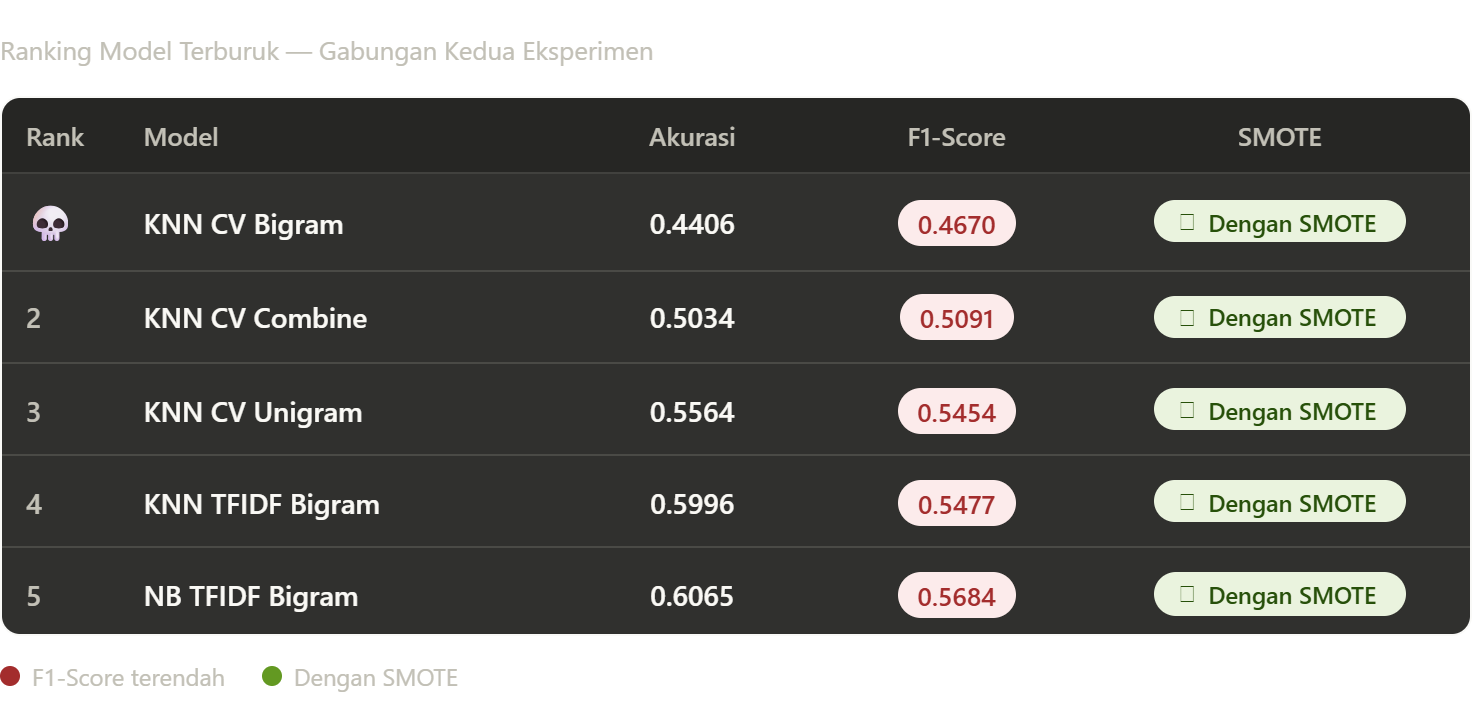

### Temuan Utama

1.   **CountVectorizer Unigram adalah metode feature extraction terbaik untuk dataset ini**
    
     CountVectorizer dengan konfigurasi unigram secara konsisten menghasilkan performa tertinggi dibandingkan bigram, combine, TF-IDF, maupun word embedding. Hal ini menunjukkan bahwa representasi kata tunggal sudah cukup mampu menangkap informasi penting dalam teks, sementara penambahan bigram justru meningkatkan dimensi fitur tanpa memberikan peningkatan performa yang signifikan.

2.   **SVM merupakan algoritma terbaik dengan performa paling optimal dan stabil**

     SVM dengan kombinasi CountVectorizer Unigram menghasilkan F1-score tertinggi sebesar 0.8109, unggul dibandingkan seluruh classifier lainnya. Logistic Regression berada di posisi kedua dengan performa yang sangat kompetitif, sementara Naive Bayes menunjukkan kestabilan tertinggi dengan gap antara akurasi train dan test yang paling kecil. KNN secara konsisten menghasilkan performa terendah di semua kombinasi feature extraction yang diuji.

3. **Random Forest mengalami overfitting yang sangat parah di seluruh kombinasi**

     Dari 35 model yang diuji dengan SMOTE, sekitar 63% mengalami penurunan F1-score dibandingkan tanpa SMOTE. Penurunan paling drastis terjadi pada KNN yang kehilangan hingga 0.17 poin F1-score. Hal ini mengindikasikan bahwa distribusi kelas pada dataset sudah cukup seimbang sehingga SMOTE tidak diperlukan, dan interpolasi vektor sintetis pada fitur sparse seperti CountVectorizer dan TF-IDF justru menghasilkan data yang tidak representatif.

4. **Bigram murni secara konsisten menghasilkan performa terburuk di semua classifier**

     Seluruh model yang menggunakan konfigurasi bigram murni, baik pada CountVectorizer maupun TF-IDF, menghasilkan F1-score terendah dibandingkan konfigurasi lainnya. Konfigurasi bigram kehilangan informasi kata tunggal yang penting sehingga representasi teksnya menjadi kurang efektif. Hal ini menegaskan bahwa untuk dataset ini, informasi level kata tunggal jauh lebih informatif dibandingkan informasi level frasa dua kata.

# Pemodelan dengan Deep Learning

### Import Library

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, LSTM, Bidirectional, Input, GRU
from sklearn.utils.class_weight import compute_class_weight

### Data Preparation

In [ ]:
df_dl = clean_df[['text_slangwords', 'Classfy']]
df_dl.head()

,text_slangwords,Classfy
0,kang teman saya tertimpa pohon di jalan sangku...,Keluhan
1,rt lapor pak lampu penerangan jalan depan kamp...,Keluhan
2,pa tempat kerja saya tanggal tetep masuk bagai...,Keluhan
3,punten sudah seminggu air pdam tidak mengalir ...,Keluhan
4,rt anak sama yang ketahuan mencuri helem di bi...,Keluhan


In [ ]:
df_dl.duplicated().sum()

np.int64(162)

In [ ]:
df_dl.drop_duplicates(inplace=True)
df_dl.duplicated().sum()

/tmp/ipykernel_3116/3141900431.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dl.drop_duplicates(inplace=True)


np.int64(0)

In [ ]:
le_dl = LabelEncoder()
df_dl['label'] = le_dl.fit_transform(df_dl['Classfy'])
num_classes = df_dl['label'].unique()

/tmp/ipykernel_3116/134518050.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dl['label'] = le_dl.fit_transform(df_dl['Classfy'])


In [ ]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    df_dl['text_slangwords'], df_dl['label'],
    test_size=0.2, random_state=42, stratify=df_dl['label']
)

# menampilkan jumlah data train dan test
print("Jumlah data train: ", X_train_dl.shape)
print("Jumlah data test : ", X_test_dl.shape)

Jumlah data train:  (3943,)
Jumlah data test :  (986,)


In [ ]:
# Melakukan class weight

# Hitung bobot otomatis berdasarkan frekuensi tiap kelas
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.7421177328230363), np.int64(1): np.float64(0.7694633408919124), np.int64(2): np.float64(2.833681280445372)}


### Tokenisasi & Padding

In [ ]:
# menghitung max_len
lengths = [len(text.split()) for text in X_train_dl]
max_len = int(np.percentile(lengths, 95))
print("max_len terpilih:", max_len)

# menghitung vocab_size
tok = Tokenizer(oov_token="<OOV>")
tok.fit_on_texts(X_train_dl)
word_counts = tok.word_counts
print("Total kata unik:", len(word_counts))

vocab_size = sum(1 for c in word_counts.values() if c >= 2) + 1
print("vocab_size terpilih:", vocab_size)

embedding_dim = 64

# Tokenizer final
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_dl)           # ← fit HANYA di train DL

X_train_seq = tokenizer.texts_to_sequences(X_train_dl)
X_test_seq  = tokenizer.texts_to_sequences(X_test_dl)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')

max_len terpilih: 21
Total kata unik: 9018
vocab_size terpilih: 3815


### Membangun arsitektur model Deep Learning

In [ ]:
def build_rnn_model(num_classes, embedding_dim=embedding_dim):
    model = Sequential(name="Model_RNN")
    model.add(Input(shape=(max_len,)))
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

    # lapisan RNN
    model.add(SimpleRNN(64))
    model.add(Dropout(0.3))

    # Beberapa lapisan Dense bertingkat
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.4))

    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))

    # alpiran output
    model.add(Dense(num_classes, activation='softmax'))
    return model

rnn_model = build_rnn_model(len(num_classes))
rnn_model.summary()

Model: "Model_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_18 (Embedding)        │ (None, 21, 64)         │       244,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_14 (SimpleRNN)       │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271,171 (1.03 MB)

 Trainable params: 271,171 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_lstm_model(num_classes, embedding_dim=embedding_dim):
    model = Sequential(name="Model_LSTM")
    model.add(Input(shape=(max_len,)))
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

    # Satu lapisan LSTM (TIDAK ditumpuk)
    model.add(LSTM(64))
    model.add(Dropout(0.3))

    # Beberapa lapisan Dense bertingkat
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.4))

    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))

    # Output
    model.add(Dense(num_classes, activation='softmax'))
    return model

lstm_model = build_lstm_model(len(num_classes))
lstm_model.summary()

Model: "Model_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ (None, 21, 64)         │       244,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,939 (1.13 MB)

 Trainable params: 295,939 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_bilstm_model(num_classes, embedding_dim=embedding_dim):
    model = Sequential(name="Model_BiLSTM")
    model.add(Input(shape=(max_len,)))
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

    model.add(Bidirectional(LSTM(64, return_sequences=True)))
    model.add(Dropout(0.3))

    model.add(Bidirectional(LSTM(32))) # lapisan kedua: output terakhir
    model.add(Dropout(0.3))

    model.add(Dense(128, activation='relu'));
    model.add(Dropout(0.4))

    model.add(Dense(64,  activation='relu'));
    model.add(Dropout(0.3))

    model.add(Dense(32,  activation='relu'));
    model.add(Dropout(0.2))

    model.add(Dense(num_classes, activation='softmax'))
    return model

bilstm_model = build_bilstm_model(len(num_classes))
bilstm_model.summary()

Model: "Model_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_22 (Embedding)        │ (None, 21, 64)         │       244,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 21, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 370,179 (1.41 MB)

 Trainable params: 370,179 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling

In [ ]:
for model in (rnn_model, lstm_model, bilstm_model):
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

### Training Model Deep Learning

In [ ]:
# Melakukan training model RNN
history_rnn = rnn_model.fit(
    X_train_pad, y_train_dl,
    validation_split=0.2,
    epochs=20, batch_size=32,
    class_weight=class_weight_dict,
    # callbacks=[early_stop]
)

Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.4667 - loss: 0.7937 - val_accuracy: 0.4918 - val_loss: 0.7527
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5457 - loss: 0.6251 - val_accuracy: 0.5108 - val_loss: 0.7355
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5479 - loss: 0.5665 - val_accuracy: 0.5120 - val_loss: 0.7081
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5878 - loss: 0.5313 - val_accuracy: 0.4778 - val_loss: 0.7756
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6535 - loss: 0.5065 - val_accuracy: 0.5082 - val_loss: 0.7374
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7911 - loss: 0.3969 - val_accuracy: 0.5463 - val_loss: 0.8590
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9093 - loss: 0.2207 - val_accuracy: 0.5513 - val_loss: 1.0884
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9461 - loss: 0.1404 - val_accuracy: 0.5577 - 

In [ ]:
# Melakukan training model LSTM
history_lstm = lstm_model.fit(
    X_train_pad, y_train_dl,
    validation_split=0.2,
    epochs=20, batch_size=32,
    class_weight=class_weight_dict,
    # callbacks=[early_stop]
)

Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.4702 - loss: 0.8549 - val_accuracy: 0.5665 - val_loss: 0.7593
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5463 - loss: 0.6087 - val_accuracy: 0.5019 - val_loss: 0.7019
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5333 - loss: 0.5633 - val_accuracy: 0.5729 - val_loss: 0.6721
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5571 - loss: 0.5333 - val_accuracy: 0.5856 - val_loss: 0.7287
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5986 - loss: 0.5020 - val_accuracy: 0.7503 - val_loss: 0.6113
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8177 - loss: 0.3837 - val_accuracy: 0.8023 - val_loss: 0.5050
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9128 - loss: 0.2386 - val_accuracy: 0.7921 - val_loss: 0.4767
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9458 - loss: 0.1506 - val_accuracy: 0.8048 - v

In [ ]:
# Melakukan training model BiLSTM
history_bilstm = bilstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=50, batch_size=32,
    class_weight=class_weight_dict,
    # callbacks=[early_stop]
)

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.3377 - loss: 1.1030 - val_accuracy: 0.1153 - val_loss: 1.1091
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.2949 - loss: 1.1021 - val_accuracy: 0.4221 - val_loss: 1.0971
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.2755 - loss: 1.1017 - val_accuracy: 0.3118 - val_loss: 1.1024
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.2705 - loss: 1.1019 - val_accuracy: 0.3954 - val_loss: 1.0723
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.3744 - loss: 1.0563 - val_accuracy: 0.3650 - val_loss: 1.0902
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.4632 - loss: 0.9017 - val_accuracy: 0.3498 - val_loss: 1.1485
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.4937 - loss: 0.7795 - val_accuracy: 0.3739 - val_loss: 1.2514
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.5162 - loss: 0.6693 - val_accuracy: 0.3853 - 

### Evaluasi model Deep Learning

In [ ]:
def evaluate(model, name):
    y_pred = np.argmax(model.predict(X_test_pad), axis=1)
    print(f"\nCllasicication report {name}")
    print("Macro F1:", round(f1_score(y_test_dl, y_pred, average='macro'), 4))
    print(classification_report(y_test_dl, y_pred, target_names=encoder.classes_))

In [ ]:
evaluate(rnn_model,  "Model RNN")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Cllasicication report Model RNN
Macro F1: 0.6736
              precision    recall  f1-score   support

     Keluhan       0.59      0.61      0.60       451
       NotKR       0.57      0.56      0.56       432
      Respon       0.89      0.83      0.86       103

    accuracy                           0.61       986
   macro avg       0.68      0.66      0.67       986
weighted avg       0.61      0.61      0.61       986



In [ ]:
evaluate(lstm_model, "Model LSTM")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Cllasicication report Model LSTM
Macro F1: 0.8287
              precision    recall  f1-score   support

     Keluhan       0.83      0.80      0.82       451
       NotKR       0.78      0.82      0.80       432
      Respon       0.90      0.84      0.87       103

    accuracy                           0.81       986
   macro avg       0.84      0.82      0.83       986
weighted avg       0.82      0.81      0.81       986



In [ ]:
evaluate(bilstm_model, "Model BiLSTM")

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step

Cllasicication report Model BiLSTM
Macro F1: 0.3737
              precision    recall  f1-score   support

     Keluhan       0.46      0.51      0.49       451
       NotKR       0.45      0.40      0.42       432
      Respon       0.21      0.21      0.21       103

    accuracy                           0.43       986
   macro avg       0.37      0.37      0.37       986
weighted avg       0.43      0.43      0.43       986



# Pemodelan dengan Pre-Trainded Transformer Model

### Import Library

In [ ]:
!pip install -q transformers datasets evaluate accelerate

In [ ]:
import numpy as np
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from datasets import Dataset
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

/usr/local/lib/python3.12/dist-packages/torch_xla/__init__.py:246: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


### Data Preparation

In [ ]:
# Gunakan teks yang masih utuh
X = clean_df['text_slangwords'].values
encoder = LabelEncoder()
y = encoder.fit_transform(clean_df['Classfy'].values)   # label 0,1,2
num_labels = len(encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ubah ke format HuggingFace Dataset
train_ds = Dataset.from_dict({"text": list(X_train), "label": list(y_train)})
test_ds  = Dataset.from_dict({"text": list(X_test),  "label": list(y_test)})

### Tokenisasi (dengan Tokenizer IndoBERT)

In [ ]:
MODEL_NAME = "indobenchmark/indobert-base-p1"
# Alternatif khusus tweet: "indolem/indobertweet-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 64

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/4072 [00:00<?, ? examples/s]

Map:   0%|          | 0/1019 [00:00<?, ? examples/s]

### Model Loading

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label={i: c for i, c in enumerate(encoder.classes_)},
    label2id={c: i for i, c in enumerate(encoder.classes_)},
)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Imbalance Handling

In [ ]:
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float)
print("Class weights:", class_weights)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

Class weights: tensor([0.7421, 0.7695, 2.8337])


### Configure & Training Model

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./indobert-tweet",
    num_train_epochs=4,                 # BERT cukup 3-5 epoch
    learning_rate=2e-5,                 # LR kecil khas fine-tuning BERT
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    weight_decay=0.01,
    logging_steps=50,
    optim="adamw_torch",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.368280,0.389687,0.824338,0.834551
2,0.211171,0.371206,0.857704,0.865545
3,0.109908,0.494312,0.882237,0.894351
4,0.028513,0.544968,0.884200,0.894866


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1020, training_loss=0.20398588881773108, metrics={'train_runtime': 1980.2823, 'train_samples_per_second': 8.241, 'train_steps_per_second': 0.515, 'total_flos': 262570746303936.0, 'train_loss': 0.20398588881773108, 'epoch': 4.0})

### Evaluation

In [ ]:
preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Macro F1 :", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Accuracy : 0.8842001962708538
Macro F1 : 0.8948659067321145
              precision    recall  f1-score   support

     Keluhan       0.87      0.91      0.89       458
       NotKR       0.89      0.84      0.86       441
      Respon       0.93      0.93      0.93       120

    accuracy                           0.88      1019
   macro avg       0.89      0.90      0.89      1019
weighted avg       0.88      0.88      0.88      1019

